In [2]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/airline-delay/Airline_Delay_Cause.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

# Data Loading

In [4]:
df = pd.read_csv("/kaggle/input/airline-delay/Airline_Delay_Cause.csv")  
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",72.0,5.0,2.46,1.00,...,0.0,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0
1,2023,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,7.0,4.25,0.00,...,0.0,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0
2,2023,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",95.0,10.0,5.94,0.00,...,0.0,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0
3,2023,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",23.0,2.0,0.56,0.00,...,0.0,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0
4,2023,12,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",2111.0,256.0,76.88,8.75,...,0.0,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0


# Airline Delay Prediction Project

# **Data Preprocessing**

In [5]:
df.dropna(inplace=True)  #  Drops all rows with at least one NaN value

In [9]:
df.isnull().sum()

year                               0
month                              0
carrier                            0
carrier_name                       0
airport                            0
airport_name                       0
arr_flights                        0
arr_del15                          0
carrier_ct                         0
weather_ct                         0
nas_ct                             0
security_ct                        0
late_aircraft_ct                   0
arr_cancelled                      0
arr_diverted                       0
arr_delay                          0
carrier_delay                      0
weather_delay                      0
nas_delay                          0
security_delay                     0
late_aircraft_delay                0
avg_delay_per_delayed_flight    8373
dtype: int64

In [10]:
df['avg_delay_per_delayed_flight'] = df['arr_delay'] / df['arr_del15']

In [11]:
delayed_data = df[df['arr_del15'] > 0].copy()

In [12]:
categorical_features = ['carrier', 'airport', 'month']
numerical_features = [
    'arr_flights',  # Total volume matters for context
    'arr_del15',    # Number of delayed flights
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct',
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# **Model Evaluation**

In [9]:
X = delayed_data[categorical_features + numerical_features]
y = delayed_data['avg_delay_per_delayed_flight']  # Correct target: average delay time for delayed flights

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [19]:
from xgboost import XGBRegressor  #  Import XGBoost

In [11]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor  # Import XGBoost

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, solver='cholesky', fit_intercept=False),  #  Fixed
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

In [12]:
results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),  #  preprocessing step
        ('regressor', model)
    ])
    
    print(f"\nTraining {name}...")
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'pipeline': pipeline,
        'predictions': y_pred
    }
    
    print(f"{name} - MAE: {mae:.2f} min, RMSE: {rmse:.2f} min, R²: {r2:.4f}")


Training Linear Regression...
Linear Regression - MAE: 19.45 min, RMSE: 35.48 min, R²: 0.0808

Training Ridge Regression...
Ridge Regression - MAE: 19.45 min, RMSE: 35.47 min, R²: 0.0812

Training Random Forest...
Random Forest - MAE: 17.96 min, RMSE: 35.85 min, R²: 0.0615

Training Gradient Boosting...
Gradient Boosting - MAE: 18.85 min, RMSE: 35.04 min, R²: 0.1034

Training XGBoost...
XGBoost - MAE: 18.86 min, RMSE: 34.93 min, R²: 0.1090


In [13]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': results['Random Forest']['predictions']  # change model name if needed
})

print(comparison_df.head(10))  #  shows side-by-side comparison

       Actual  Predicted
0   41.000000  54.088762
1   22.000000  60.219667
2   36.590909  36.662057
3   59.795455  47.618778
4   41.500000  42.769167
5  195.000000  47.445000
6   68.486339  67.995265
7   69.657143  77.328393
8   56.000000  63.231595
9   62.840909  65.569225


In [14]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': results['Gradient Boosting']['predictions']  # change model name if needed
})

print(comparison_df.head(10))  #  shows side-by-side comparison

       Actual  Predicted
0   41.000000  64.259319
1   22.000000  62.591945
2   36.590909  44.846956
3   59.795455  62.236717
4   41.500000  68.526899
5  195.000000  57.930475
6   68.486339  68.845566
7   69.657143  74.429848
8   56.000000  73.827447
9   62.840909  61.057960


# **Predicting the total no. of delayed flight**

In [28]:
categorical_features = ['carrier', 'airport', 'month']
numerical_features = [
    'arr_flights',  # total arrivals
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct'  # delay causes
]

X = df[categorical_features + numerical_features]
y = df['arr_del15']  # ✅ Predict total number of delayed flights

In [29]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} flights")
print(f"RMSE: {rmse:.2f} flights")
print(f"R²: {r2:.4f}")

MAE: 2.24 flights
RMSE: 7.23 flights
R²: 0.9980


GradientBoostingRegressor is the best model here

In [32]:
comparison_df = pd.DataFrame({
    'Actual_Delayed_Flights': y_test.values,
    'Predicted_Delayed_Flights': y_pred
})

comparison_df['Predicted_Delayed_Flights'] = comparison_df['Predicted_Delayed_Flights'].round()

print(comparison_df.head(10))

   Actual_Delayed_Flights  Predicted_Delayed_Flights
0                     8.0                        8.0
1                    56.0                       64.0
2                     7.0                        7.0
3                     4.0                        4.0
4                     3.0                        3.0
5                    45.0                       47.0
6                    14.0                       13.0
7                     6.0                        6.0
8                    63.0                       63.0
9                     3.0                        3.0


# **Predict total minutes of  all delayed flights**

In [13]:
categorical_features = ['carrier', 'airport', 'month']
numerical_features = [
    'arr_flights',  # total arrivals
    'arr_del15', #total no . of delyaed flight
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct'  # delay causes
]

X = df[categorical_features + numerical_features]
y = df['arr_delay']  #  Predict total minutes of delayed flights

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} flights")
print(f"RMSE: {rmse:.2f} flights")
print(f"R²: {r2:.4f}")

MAE: 641.82 flights
RMSE: 1879.13 flights
R²: 0.9733


In [37]:
categorical_features = ['carrier', 'airport', 'month']
numerical_features = [
    'arr_flights',  # total arrivals
    'arr_del15', #total no . of delyaed flight
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct'  # delay causes
]

X = df[categorical_features + numerical_features]
y = df['arr_delay']  #  Predict total minutes of delayed flights

In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [20]:
models = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    
    print(f"\n{name} Results:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")


Linear Regression Results:
MAE: 936.86
RMSE: 2436.30
R2 Score: 0.9551

Gradient Boosting Results:
MAE: 641.82
RMSE: 1879.13
R2 Score: 0.9733

XGBoost Results:
MAE: 692.23
RMSE: 2599.58
R2 Score: 0.9489


here also Gradient Boosting is best

# **Predicting average delay per flight**

In [18]:
df = pd.read_csv("/kaggle/input/airline-delay/Airline_Delay_Cause.csv")  
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",72.0,5.0,2.46,1.00,...,0.0,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0
1,2023,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,7.0,4.25,0.00,...,0.0,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0
2,2023,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",95.0,10.0,5.94,0.00,...,0.0,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0
3,2023,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",23.0,2.0,0.56,0.00,...,0.0,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0
4,2023,12,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",2111.0,256.0,76.88,8.75,...,0.0,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0


In [19]:
df.dropna(inplace=True)  #  Drops all rows with at least one NaN value

In [20]:
positive_count = (df['arr_del15'] > 0).sum()

negative_count = (df['arr_del15'] < 0).sum()

zero_count = (df['arr_del15'] == 0).sum()

print(f"✅ Positive values: {positive_count}")
print(f"✅ Negative values: {negative_count}")
print(f"✅ Zero values: {zero_count}")

✅ Positive values: 170374
✅ Negative values: 0
✅ Zero values: 8373


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
from xgboost import XGBRegressor  #  Import XGBoost

In [24]:
zero_count = (df['arr_del15'] == 0).sum()
print(f"Number of zeros in 'arr_del15': {zero_count}")

Number of zeros in 'arr_del15': 8373


In [25]:
df = df[df['arr_del15'] > 0].copy()  #  Keep only rows where arr_del15 is NOT zero

In [26]:
df['avg_delay_per_flight'] = df['arr_delay'] / df['arr_del15']

In [27]:
zero_count = (df['arr_del15'] == 0).sum()
print(f"Number of zeros in 'arr_del15': {zero_count}")

Number of zeros in 'arr_del15': 0


In [28]:
categorical_features = ['month', 'carrier', 'airport']
numerical_features = ['year',  'carrier_ct', 'weather_ct', 
                     'nas_ct', 'security_ct', 'late_aircraft_ct']

controllable_delays = ['carrier_delay', 'late_aircraft_delay']
non_controllable_delays = ['weather_delay', 'nas_delay', 'security_delay']

df['OAI_per_flight'] = 0
for col in controllable_delays:
    df['OAI_per_flight'] += 2 * df[col].fillna(0)  # 2x weight for controllable delays
for col in non_controllable_delays:
    df['OAI_per_flight'] += df[col].fillna(0)
df['OAI_per_flight'] = df['OAI_per_flight'] / df['arr_del15'] #per delayed flight

numerical_features.append('OAI_per_flight')

X = df[categorical_features + numerical_features]
y = df['avg_delay_per_flight']  # Target is average delay per flight

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
df['OAI_per_flight']

0         150.000000
1          94.714286
2         167.100000
3          75.000000
4         158.707031
             ...    
179333     84.880435
179334     93.022222
179335     92.161765
179336     81.653179
179337     91.325581
Name: OAI_per_flight, Length: 170374, dtype: float64

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

models = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    
    print(f"\n{name} Results:")
    print(f"MAE: {mae:.2f} minutes per flight")
    print(f"RMSE: {rmse:.2f} minutes per flight")
    print(f"R2 Score: {r2:.4f}")


Linear Regression Results:
MAE: 4.83 minutes per flight
RMSE: 10.78 minutes per flight
R2 Score: 0.9169

Gradient Boosting Results:
MAE: 3.33 minutes per flight
RMSE: 7.12 minutes per flight
R2 Score: 0.9638

XGBoost Results:
MAE: 3.72 minutes per flight
RMSE: 12.50 minutes per flight
R2 Score: 0.8882


# **Lets Try some more models**

In [13]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

models = {
    'Lasso Regression': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    
    print(f"\n{name} Results:")
    print(f"MAE: {mae:.2f} minutes per flight")
    print(f"RMSE: {rmse:.2f} minutes per flight")
    print(f"R2 Score: {r2:.4f}")


Lasso Regression Results:
MAE: 5.05 minutes per flight
RMSE: 10.98 minutes per flight
R2 Score: 0.9137

ElasticNet Results:
MAE: 4.93 minutes per flight
RMSE: 11.19 minutes per flight
R2 Score: 0.9103


# **Now Performing GridSearchCV for Gradient Boosting**

In [15]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

categorical_features = ['month', 'carrier', 'airport']
numerical_features = ['year', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'OAI_per_flight']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7]
}

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

X = df[categorical_features + numerical_features]
y = df['avg_delay_per_flight']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search = GridSearchCV(
    best_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_absolute_error'
)
grid_search.fit(X_train, y_train)

print("\n✅ Best hyperparameters:")
print(grid_search.best_params_)

final_model = grid_search.best_estimator_

y_pred_final = final_model.predict(X_test)
final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print("\n📊 Final Model Performance:")
print(f"MAE: {final_mae:.2f} minutes per flight")
print(f"RMSE: {final_rmse:.2f} minutes per flight")
print(f"R2 Score: {final_r2:.4f}")


✅ Best hyperparameters:
{'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200}

📊 Final Model Performance:
MAE: 2.44 minutes per flight
RMSE: 6.08 minutes per flight
R2 Score: 0.9735


In [1]:
# here we are using gradient boosting(data balancing is done(no need to do it))

# **Using SHAP**

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor

categorical_features = ['month', 'carrier', 'airport']
numerical_features = ['year',  'carrier_ct', 'weather_ct', 
                     'nas_ct', 'security_ct', 'late_aircraft_ct']

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

final_model.fit(X_train, y_train)  # X_train and y_train from your dataset

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'carrier_ct',
                                                   'weather_ct', 'nas_ct',
                                                   'security_ct',
                                                   'late_aircraft_ct']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'carrier',
                                                   'airport'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [35]:
def predict_flight_delay(model, carrier, airport, month, year, **kwargs):
    flight_data = pd.DataFrame({
        'carrier': [carrier],
        'airport': [airport],
        'month': [month],
        'year': [year],
        'arr_flights': [1],
        'arr_del15': [kwargs.get('arr_del15', 0)],
        'carrier_ct': [kwargs.get('carrier_ct', 0)],
        'weather_ct': [kwargs.get('weather_ct', 0)],
        'nas_ct': [kwargs.get('nas_ct', 0)],
        'security_ct': [kwargs.get('security_ct', 0)],
        'late_aircraft_ct': [kwargs.get('late_aircraft_ct', 0)],
        'OAI_per_flight': [kwargs.get('OAI_per_flight', 0)]
    })
    return model.predict(flight_data)[0]

print("\n🚀 Sample Prediction:")
sample_prediction = predict_flight_delay(
    final_model, carrier='AA', airport='ORD', month=7, year=2022
)
print(f"Predicted delay: {sample_prediction:.2f} minutes")


🚀 Sample Prediction:
Predicted delay: 75.27 minutes


In [39]:
X_train_processed = preprocessor.transform(X_train)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()  
else:
    X_train_processed = np.array(X_train_processed).astype(float)  

explainer = shap.TreeExplainer(final_model.named_steps['model'])
shap_values = explainer.shap_values(X_train_processed)  


Glyph 128204 (\N{PUSHPIN}) missing from current font.
The figure layout has changed to tight
Glyph 128204 (\N{PUSHPIN}) missing from current font.


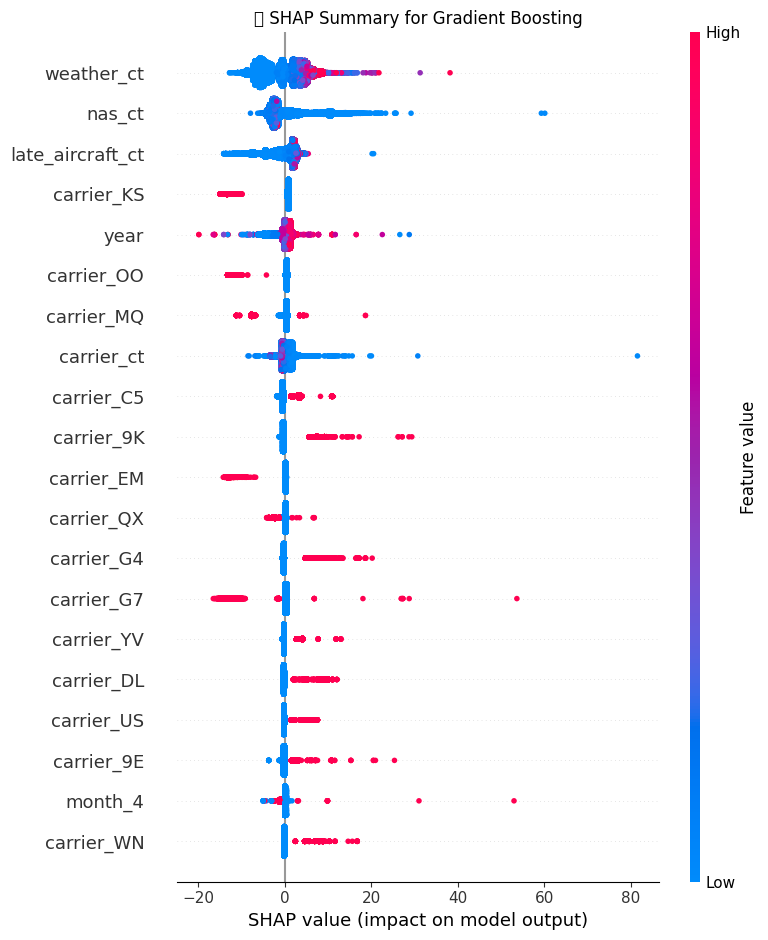

In [40]:


feature_names = []
for name, transformer, features in preprocessor.transformers_:
    if name == 'num':
        feature_names.extend(numerical_features)
    else:
        for cat_feature in categorical_features:
            cat_values = X[cat_feature].unique()
            feature_names.extend([f"{cat_feature}_{val}" for val in cat_values])

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_train_processed, feature_names=feature_names, show=False)
plt.title("📌 SHAP Summary for Gradient Boosting")
plt.tight_layout()
plt.show()

# finally gradient boosting model is best for regression